## Mnist dataset which is set of 70,000 small images of digits,handwritten by high school students and employee of the us census beureau each images is labeled with the digit it represent, we can assume this complete dataset as an example of multinomial dataset

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784',version=1,as_frame=False)

In [2]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
mnist.DESCR

"**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  \n**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  \n**Please cite**:  \n\nThe MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  \n\nIt is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 

In [4]:
X,y=mnist["data"],mnist["target"]
X.shape,y.shape

((70000, 784), (70000,))

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

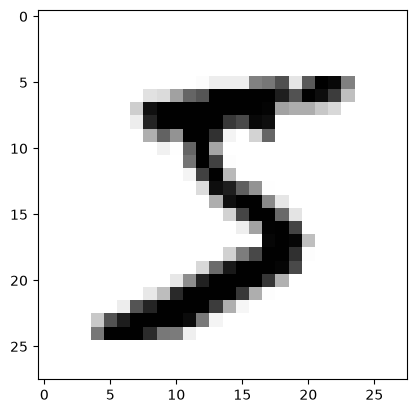

In [6]:
some_digit=X[0]
some_digit_image=some_digit.reshape(28,28)
plt.imshow(some_digit_image,cmap='binary')
plt.show()

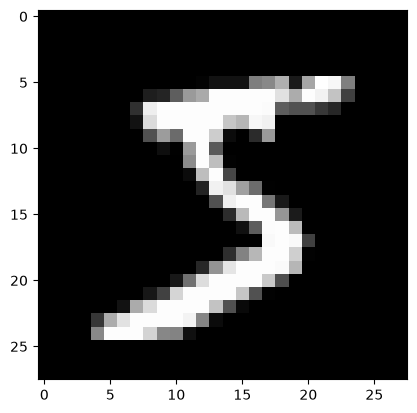

In [7]:
some_digit=X[0]
some_digit_image=some_digit.reshape(28,28)
plt.imshow(some_digit_image,cmap='gray')
plt.show()

In [8]:
def plot_digit(instances,image_per_row=10,**option):
    size=28
    image_per_row=min(len(instances),image_per_row)
    n_rows=(len(instances)-1)//image_per_row+1
    n_empty=n_rows*image_per_row-len(instances)
    padded_instances=np.concatenate([instances,np.zeros((n_empty,size*size))],axis=0)
    image_grid=padded_instances.reshape((n_rows,image_per_row,size,size))
    big_image=image_grid.transpose(0,2,1,3).reshape(n_rows*size,image_per_row*size)
    plt.imshow(big_image,cmap=mpl.cm.binary,**option)
    plt.axis("off")

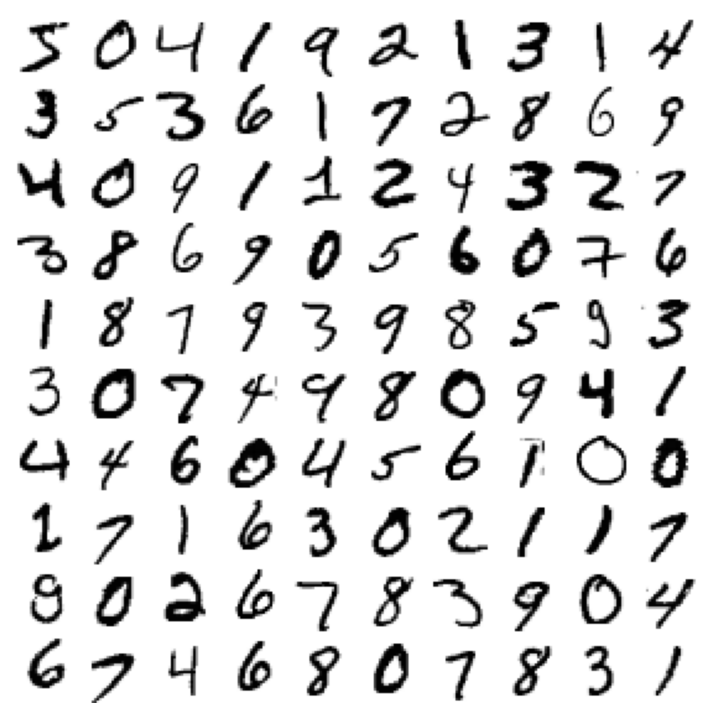

In [9]:
plt.figure(figsize=(9,9))
example_image=X[:100]
plot_digit(example_image,image_per_row=10)

In [10]:
X_train,X_test,y_train,y_test=X[:60000],X[60000:],y[:60000],y[60000:]
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((60000, 784), (60000,), (10000, 784), (10000,))

In [11]:
y_train[:10]

array(['5', '0', '4', '1', '9', '2', '1', '3', '1', '4'], dtype=object)

In [12]:
y_train_int=y_train.astype(int)
y_test_int=y_test.astype(int)

In [13]:
y_train_int[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])

In [14]:
X_test[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [15]:
X_train_dumy=X_train/255.0  #convert to 0 and 1
X_test_dumy=X_test/255.0

In [16]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression

In [17]:
log_reg=LogisticRegression(max_iter=100,solver='lbfgs')

In [18]:
log_reg.fit(X_train_dumy,y_train_int)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

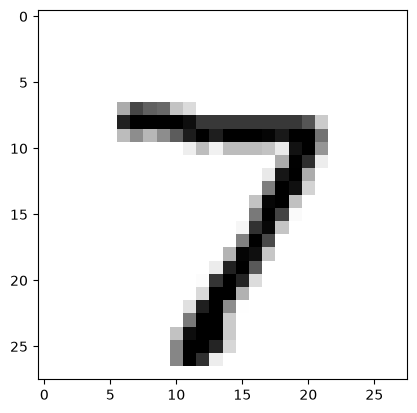

In [19]:
sample=X_test_dumy[0]
some_digit_image=sample.reshape(28,28)
plt.imshow(some_digit_image,cmap='binary')
plt.show()

In [20]:
y_pred=y_train=log_reg.predict(X_test_dumy)

In [21]:
from sklearn.metrics import accuracy_score
print("Accuracy is",accuracy_score(y_test_int,y_pred)*100)

Accuracy is 92.57


In [22]:
sample=X_test_dumy[0].reshape(1,-1)
print("actual value is",y_test_int[0])
print("Predicted:- ",log_reg.predict(sample)[0])

actual value is 7
Predicted:-  7


In [23]:
#probabilty for the sample 7
probabilities = log_reg.predict_proba(sample)
print(probabilities)

[[8.12142503e-07 7.42344243e-13 2.18891808e-06 1.74214338e-03
  1.04522391e-07 1.19598296e-05 1.31899577e-11 9.97977549e-01
  9.75701070e-06 2.55485228e-04]]


In [24]:
print("Actual :",y_test_int[0])
print("predicted:",np.argmax(probabilities))
print("confidence:",probabilities.max())

Actual : 7
predicted: 7
confidence: 0.9979775489561152


In [25]:
for digit,probability in enumerate(probabilities[0]):
    print(f"digit:-{digit}:{probability:.10f}")

digit:-0:0.0000008121
digit:-1:0.0000000000
digit:-2:0.0000021889
digit:-3:0.0017421434
digit:-4:0.0000001045
digit:-5:0.0000119598
digit:-6:0.0000000000
digit:-7:0.9979775490
digit:-8:0.0000097570
digit:-9:0.0002554852


In [26]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test_int,y_pred)
cm

array([[ 959,    0,    0,    3,    1,    7,    5,    4,    1,    0],
       [   0, 1111,    4,    2,    0,    2,    3,    2,   11,    0],
       [   6,    9,  926,   16,    9,    4,   13,    6,   39,    4],
       [   4,    1,   18,  917,    1,   22,    4,   11,   25,    7],
       [   1,    1,    7,    3,  914,    0,   10,    4,   10,   32],
       [  10,    2,    3,   34,    7,  783,   14,    6,   29,    4],
       [   9,    3,    8,    2,    7,   14,  912,    2,    1,    0],
       [   1,    8,   24,    5,    7,    1,    0,  950,    3,   29],
       [   9,   11,    8,   23,    7,   25,   12,    7,  860,   12],
       [   9,    8,    0,   11,   24,    6,    0,   19,    7,  925]])

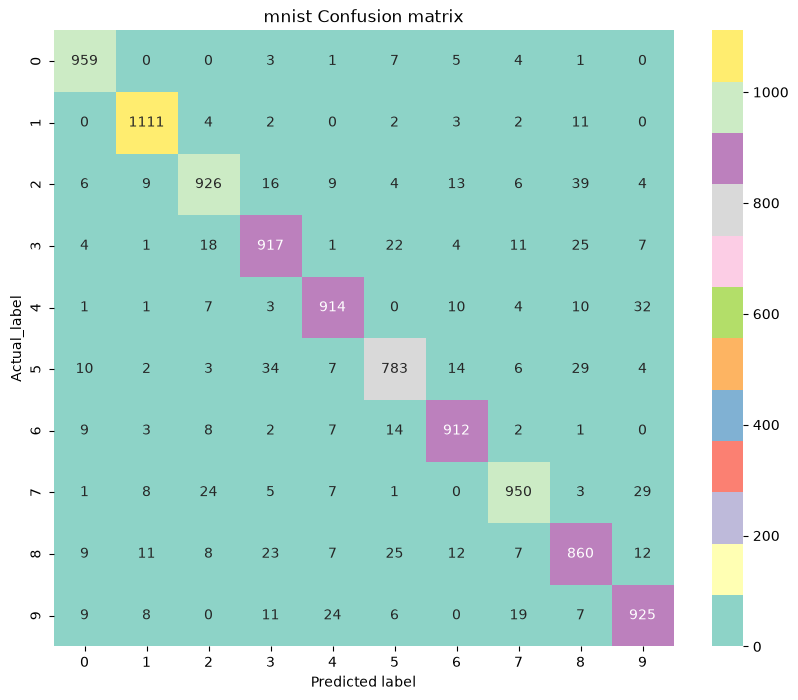

In [27]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d",cmap="Set3",
            xticklabels=range(10),yticklabels=range(10)
           )
plt.xlabel("Predicted label")
plt.ylabel("Actual_label")
plt.title("mnist Confusion matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

In [29]:
print (classification_report(y_test_int,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.93      0.93       982
           5       0.91      0.88      0.89       892
           6       0.94      0.95      0.94       958
           7       0.94      0.92      0.93      1028
           8       0.87      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



In [30]:
y_prob=log_reg.predict_proba(X_test_dumy)
y_prob

array([[8.12142503e-07, 7.42344243e-13, 2.18891808e-06, ...,
        9.97977549e-01, 9.75701070e-06, 2.55485228e-04],
       [2.53014315e-04, 3.37725569e-07, 9.94589404e-01, ...,
        3.28234960e-18, 1.78758511e-04, 4.61061741e-14],
       [9.35776946e-08, 9.87504730e-01, 7.58171520e-03, ...,
        9.04782338e-04, 1.70672708e-03, 1.26505999e-04],
       ...,
       [3.45129601e-09, 1.20519733e-09, 5.89296795e-06, ...,
        8.59710466e-04, 1.73775985e-02, 2.13473765e-02],
       [2.47103557e-07, 3.64698475e-07, 1.37950624e-07, ...,
        1.10303165e-08, 1.83505105e-03, 1.06960383e-07],
       [7.12888213e-07, 6.75019354e-15, 7.23853498e-05, ...,
        5.56091019e-12, 1.68071798e-07, 2.90740146e-10]],
      shape=(10000, 10))

In [31]:
from sklearn.preprocessing  import label_binarize
from sklearn.metrics import roc_curve,auc
y_prob=log_reg.predict_proba(X_test_dumy)
y_test_int=label_binarize(y_test_int,classes=range(10))

fpr={}
tpr={}
roc_auc={}
for i in range(10):
    fpr[i],tpr[i],_=roc_curve(y_test_int[:,i],y_prob[:,i])
    roc_auc[i]=auc(fpr[i],tpr[i])

In [32]:
for i in range(10):
    print(f"Digit{i}:AUC={roc_auc[i]:.4f}")

Digit0:AUC=0.9991
Digit1:AUC=0.9985
Digit2:AUC=0.9886
Digit3:AUC=0.9935
Digit4:AUC=0.9962
Digit5:AUC=0.9893
Digit6:AUC=0.9982
Digit7:AUC=0.9943
Digit8:AUC=0.9892
Digit9:AUC=0.9926


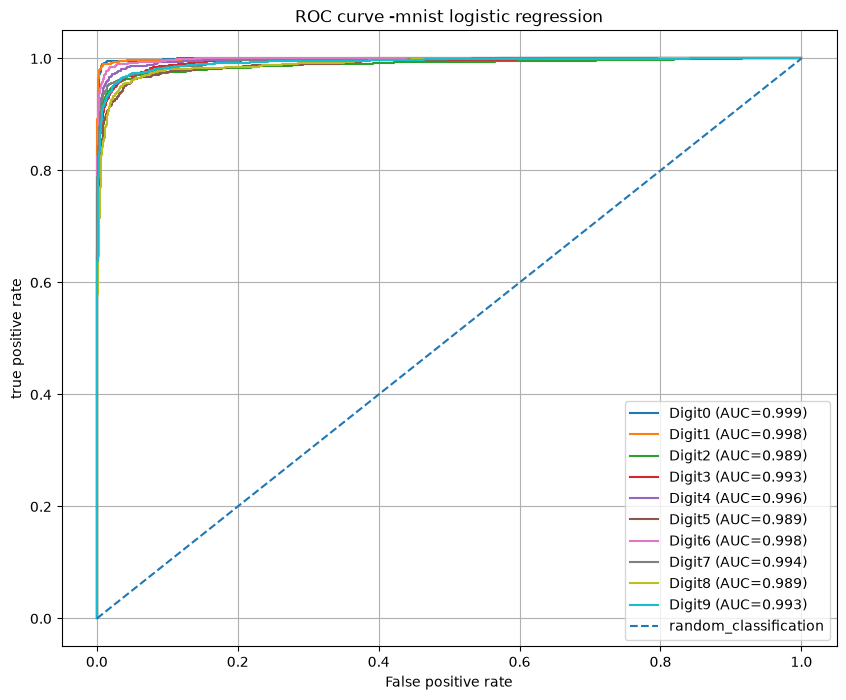

In [33]:
plt.figure(figsize=(10,8))
for i in range(10):
    plt.plot(fpr[i],tpr[i],label=f"Digit{i} (AUC={roc_auc[i]:.3f})")
plt.plot([0,1],[0,1],linestyle="--",label="random_classification")
plt.xlabel("False positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve -mnist logistic regression")
plt.legend()
plt.grid()
plt.show()

In [34]:
import joblib

In [35]:
joblib.dump(log_reg,"mnist_logistic_model.pkl")

['mnist_logistic_model.pkl']

In [36]:
from PIL import Image
import numpy as np

In [37]:
image=Image.open("OIP.jpg")
image=image.convert("L")
image=image.resize((28,28))
image_array=np.array(image)
image_array=image_array/255.0
image_array=image_array.reshape(1,784)

In [38]:
image_array.shape

(1, 784)

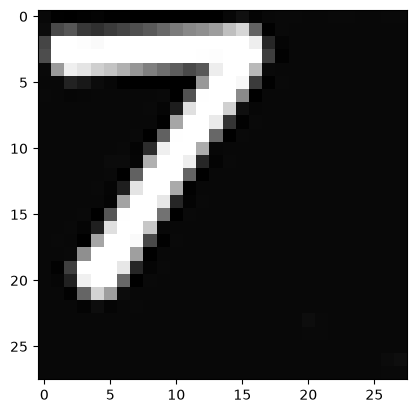

In [39]:
plt.imshow(image_array.reshape(28,28),cmap='binary')
plt.show()

In [40]:
import joblib

In [41]:
model = joblib.load("mnist_logistic_model.pkl")

In [42]:
prediction = model.predict(image_array)
print("predicted digit:",prediction[0])

predicted digit: 3


In [46]:
import cv2

# !pip install opencv-python

(1056, 840, 3)


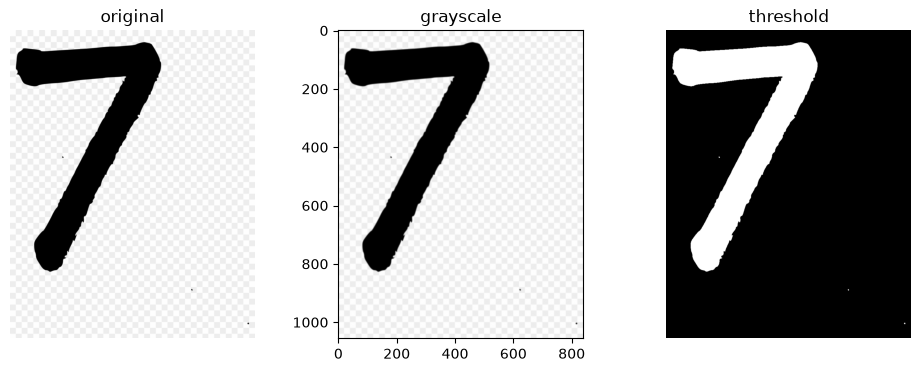

In [50]:
image=cv2.imread("OIP.jpg")
print(image.shape)
#convert to gray scale
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

#BLUR
gray=cv2.GaussianBlur(gray,(5,5),0)

_,threshold=cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray,cmap='gray')
plt.title("grayscale")

plt.subplot(1,3,3)
plt.imshow(threshold,cmap='gray')
plt.title("threshold")
plt.axis("off")
plt.show()